<a href="https://colab.research.google.com/github/MalathyParamasivam/dummyy/blob/main/Python%20For%20Data%20Analysis-Social%20Media%20Engagement%20AnalyticsUntitled20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Social Media Engagement Analytics Using Python**



In [ ]:
!pip install pandas numpy seaborn requests
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import requests
import matplotlib.pyplot as plt

#**1.Data Import & Setup**

In [ ]:
url=("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")
df=pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


#**Data Exploration**

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [ ]:
df.describe(include="object")

,gender,country,post_type,post_category,posted_at,device_type,sentiment,hashtags
count,4850,5000,5000,5000,5000,5000,4850,5000
unique,3,10,4,8,729,3,3,761
top,Male,India,reel,fitness,26-12-2023,mobile,positive,#tech
freq,1699,535,1283,675,16,1684,2363,201


In [ ]:
df.shape

(5000, 19)

**Check/convert data types**

In [ ]:
#Converting posted_at from object to datetime
df["posted_at"]=pd.to_datetime(df["posted_at"])

#**2.Data Cleaning**

**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


**Handling missing values using (mean,median,mode)**

In [ ]:
#age
df["age"]=df["age"].fillna(df["age"].mean())

#Gender
df["gender"]=df["gender"].fillna(df["gender"].mode()[0])

#likes
df["likes"]=df["likes"].fillna(df["likes"].median())

#Comment
df["comments"]=df["comments"].fillna(df["comments"].median())

#shares
df["shares"]=df["shares"].fillna(df["shares"].median())

#sentiments
df["sentiment"]=df["sentiment"].fillna(df["sentiment"].mode()[0])


In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


**Duplicate Handling**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Data Formatting**

In [ ]:
#age
df["age"] = df["age"].astype(int)

#likes
df["likes"]=df["likes"].astype(int)

#comments
df["comments"]=df["comments"].astype(int)

#shares
df["shares"]=df["shares"].astype(int)

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


**Feature Cleaning**

**Extract hashtag count**

In [ ]:
df["hashtag_count"]=df["hashtags"].str.count("#")

**Clean sentiment labels**

In [ ]:
df["sentiment"]=df["sentiment"].str.upper().str.strip()

#**3.Data Exploration using Pandas**

**View dataset structure using head(), tail(), shape, and columns.**

In [ ]:
#head
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,NEGATIVE,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,NEGATIVE,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,POSITIVE,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,NEGATIVE,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,NEGATIVE,#travel,2.777372


In [ ]:
#tail
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,POSITIVE,#travel #fun,0.466761
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,NEGATIVE,#foodie #reels,0.621155
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,POSITIVE,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,POSITIVE,#reels #love #fitness,0.223518
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,NEUTRAL,#foodie #lifestyle #fashion,1.203527


In [ ]:
#shape
df.shape

(5000, 19)

In [ ]:
#columns
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

**Check data types and info with info() and dtypes.**

In [ ]:
#Data type
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
#Generate summary statistics using describe
df.describe(include="object")

,gender,country,post_type,post_category,device_type,sentiment,hashtags
count,5000,5000,5000,5000,5000,5000,5000
unique,3,10,4,8,3,3,761
top,Male,India,reel,fitness,mobile,POSITIVE,#tech
freq,1849,535,1283,675,1684,2513,201


In [ ]:
#Analyze categorical distributions using value_counts(), unique(), and nunique().

#gender
df["gender"].value_counts(),df["age"].unique(),df["age"].nunique()

(gender
 Male      1849
 Other     1581
 Female    1570
 Name: count, dtype: int64,
 array([43, 33, 32, 51, 34, 16, 25, 57, 54, 62, 61, 64, 29, 48, 45, 13, 27,
        36, 20, 39, 35, 58, 38, 59, 49, 37, 28, 14, 30, 42, 44, 41, 55, 60,
        52, 31, 21, 22, 56, 47, 23, 46, 24, 26, 63, 18, 50, 53, 40, 15, 17,
        19]),
 52)

In [ ]:
#Country
df["country"].value_counts(),df["country"].unique(),df["country"].nunique()

(country
 India        535
 Canada       513
 Brazil       504
 UAE          503
 USA          501
 France       496
 UK           493
 Australia    493
 Germany      490
 Japan        472
 Name: count, dtype: int64,
 array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
        'UAE', 'Germany', 'USA'], dtype=object),
 10)

In [ ]:
#post_type
df["post_type"].value_counts(),df["post_type"].unique,df["post_type"].nunique()

(post_type
 reel     1283
 image    1247
 text     1245
 video    1225
 Name: count, dtype: int64,
 <bound method Series.unique of 0       image
 1        reel
 2        text
 3        text
 4       image
         ...  
 4995    video
 4996     reel
 4997     text
 4998    video
 4999     text
 Name: post_type, Length: 5000, dtype: object>,
 4)

In [ ]:
#post_category
df["post_category"].value_counts(),df["post_category"].unique(),df["post_category"].nunique()

(post_category
 fitness      675
 tech         665
 music        635
 education    631
 lifestyle    607
 travel       600
 fashion      594
 food         593
 Name: count, dtype: int64,
 array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
        'education', 'music'], dtype=object),
 8)

In [ ]:
#device_type
df["device_type"].value_counts(),df["device_type"].unique(),df["device_type"].nunique()

(device_type
 mobile     1684
 tablet     1658
 desktop    1658
 Name: count, dtype: int64,
 array(['mobile', 'tablet', 'desktop'], dtype=object),
 3)

In [ ]:
#sentiment
df["sentiment"].value_counts(),df["sentiment"].unique(),df["sentiment"].nunique()

(sentiment
 POSITIVE    2513
 NEUTRAL     1527
 NEGATIVE     960
 Name: count, dtype: int64,
 array(['NEGATIVE', 'POSITIVE', 'NEUTRAL'], dtype=object),
 3)

In [ ]:
#Create a correlation matrix for numeric fields.
df.corr(numeric_only=True)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016199,0.093521
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292
is_verified,0.004058,-0.000079,0.025208,-0.016199,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528


In [ ]:
crr=df[["likes","shares","comments","impression_count"]].corr()
print(crr)

                     likes    shares  comments  impression_count
likes             1.000000  0.004712 -0.018421          0.007952
shares            0.004712  1.000000  0.006142         -0.005204
comments         -0.018421  0.006142  1.000000         -0.009395
impression_count  0.007952 -0.005204 -0.009395          1.000000


In [ ]:
#Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

df["age_group"]=pd.cut(df["age"],bins=[0,17,59,100],labels=["children","adult","old"])
df["age_group"].value_counts()

,count
age_group,
adult,4092
old,460
children,448


In [ ]:
#Average likes by post type
df.groupby("post_type")["likes"].mean()

,likes
post_type,
image,10104.852446
reel,10037.784879
text,10100.132530
video,10188.586122


In [ ]:
#post_category by country

df.groupby(["post_category","country"]).size()

post_category  country  
education      Australia    51
               Brazil       58
               Canada       75
               France       79
               Germany      54
                            ..
travel         India        59
               Japan        46
               UAE          65
               UK           58
               USA          67
Length: 80, dtype: int64

In [ ]:
#post category by age and country

df.groupby(["post_category","age","country"]).size()

post_category  age  country  
education      13   Australia    1
                    Brazil       1
                    France       2
                    Germany      1
                    Japan        1
                                ..
travel         64   Canada       3
                    France       1
                    Japan        1
                    UAE          2
                    USA          2
Length: 2853, dtype: int64

In [ ]:
#Average Shares by post category and country

df.groupby(["post_category","country"])["shares"].mean()

post_category  country  
education      Australia     899.450980
               Brazil        947.258621
               Canada       1131.800000
               France       1129.962025
               Germany       907.055556
                               ...     
travel         India        1095.288136
               Japan         987.195652
               UAE          1023.707692
               UK            999.810345
               USA           921.776119
Name: shares, Length: 80, dtype: float64

In [ ]:
#Average sentiment by country

df.groupby(["country","sentiment"]).count()

user_id  age  gender  post_id  post_type  post_category  \
country   sentiment                                                            
Australia NEGATIVE        89   89      89       89         89             89   
          NEUTRAL        159  159     159      159        159            159   
          POSITIVE       245  245     245      245        245            245   
Brazil    NEGATIVE        99   99      99       99         99             99   
          NEUTRAL        157  157     157      157        157            157   
          POSITIVE       248  248     248      248        248            248   
Canada    NEGATIVE        94   94      94       94         94             94   
          NEUTRAL        151  151     151      151        151            151   
          POSITIVE       268  268     268      268        268            268   
France    NEGATIVE       103  103     103      103        103            103   
          NEUTRAL        142  142     142      142        142            142   
          POSITIVE       251  251     251      251        251            251   
Germany   NEGATIVE        79   79      79       79         79             79   
          NEUTRAL        151  151     151      151        151            151   
          POSITIVE       260  260     260      260        260            260   
India     NEGATIVE       107  107     107      107        107            107   
          NEUTRAL        151  151     151      151        151            151   
          POSITIVE       277  277     277      277        277            277   
Japan     NEGATIVE        97   97      97       97         97             97   
          NEUTRAL        153  153     153      153        153            153   
          POSITIVE       222  222     222      222        222            222   
UAE       NEGATIVE        92   92      92       92         92             92   
          NEUTRAL        150  150     150      150        150            150   
          POSITIVE       261  261     261      261        261            261   
UK        NEGATIVE       112  112     112      112        112            112   
          NEUTRAL        145  145     145      145        145            145   
          POSITIVE       236  236     236      236        236            236   
USA       NEGATIVE        88   88      88       88         88             88   
          NEUTRAL        168  168     168      168        168            168   
          POSITIVE       245  245     245      245        245            245   

                     likes  comments  shares  watch_time_sec  \
country   sentiment                                            
Australia NEGATIVE      89        89      89              89   
          NEUTRAL      159       159     159             159   
          POSITIVE     245       245     245             245   
Brazil    NEGATIVE      99        99      99              99   
          NEUTRAL      157       157     157             157   
          POSITIVE     248       248     248             248   
Canada    NEGATIVE      94        94      94              94   
          NEUTRAL      151       151     151             151   
          POSITIVE     268       268     268             268   
France    NEGATIVE     103       103     103             103   
          NEUTRAL      142       142     142             142   
          POSITIVE     251       251     251             251   
Germany   NEGATIVE      79        79      79              79   
          NEUTRAL      151       151     151             151   
          POSITIVE     260       260     260             260   
India     NEGATIVE     107       107     107             107   
          NEUTRAL      151       151     151             151   
          POSITIVE     277       277     277             277   
Japan     NEGATIVE      97        97      97              97   
          NEUTRAL      153       153     153             153   
          POSITIVE     222       222     222        

In [ ]:
#impression count by country

df.groupby("country")["impression_count"].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
#Gender by post category and country

df.groupby(["country","gender","post_category"]).size()

country    gender  post_category
Australia  Female  education        20
                   fashion          25
                   fitness          26
                   food             17
                   lifestyle        16
                                    ..
USA        Other   food             17
                   lifestyle        18
                   music            22
                   tech             14
                   travel           17
Length: 240, dtype: int64

#**4.Data Wrangling**

In [ ]:
#Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
df["engagement_score"]=df["likes"]+df["shares"]+df["comments"]

df["hashtag_count"]=df["hashtags"].str.count("#")

In [ ]:
#Perform groupby summaries by post_type, country, and sentiment.
df.groupby(["post_type","country","sentiment"])["likes"].mean()

post_type  country    sentiment
image      Australia  negative      7889.500000
                      neutral       9673.390244
                      positive     10195.724138
           Brazil     negative      7559.350000
                      neutral       8332.545455
                                       ...     
video      UK         neutral      10296.371429
                      positive      8867.483871
           USA        negative     10290.450000
                      neutral       9592.750000
                      positive      9609.627451
Name: likes, Length: 120, dtype: float64

#**5.Statistical Analysis**

**Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:**

In [ ]:
#mean
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].mean()

,0
likes,10107.043711
comments,1502.195670
shares,1002.629485
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
#median
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
#mode
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,6486.0,2934.0,138.0,916.0,0.006363,497502.0
1,8151.0,NaN,319.0,2145.0,0.007420,NaN
2,10943.0,NaN,397.0,4360.0,0.012676,NaN
3,13536.0,NaN,424.0,7003.0,0.012692,NaN
4,15718.0,NaN,437.0,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [ ]:
#Standard deviation
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].std()

,0
likes,5789.819252
comments,869.537889
shares,579.615158
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
#Variance
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].var()

,0
likes,3.352201e+07
comments,7.560961e+05
shares,3.359537e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
#Percentiles
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].quantile([0,0.25,0.50,0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.00,10.0,0.0,0.0,0.00,0.006363,87.00
0.25,5068.5,760.0,498.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.0,1012.0,4034.50,0.253896,388982.00
0.75,15115.0,2256.0,1501.0,6020.25,0.504794,589744.25


In [ ]:
#skewness
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].skew()

,0
likes,-0.006813
comments,0.003206
shares,-0.012977
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
#kurtosis
df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].kurt()

,0
likes,-1.205547
comments,-1.200096
shares,-1.202503
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


#**Data Visualization**

**Matplotlib**

**Scatter: likes vs impressions**

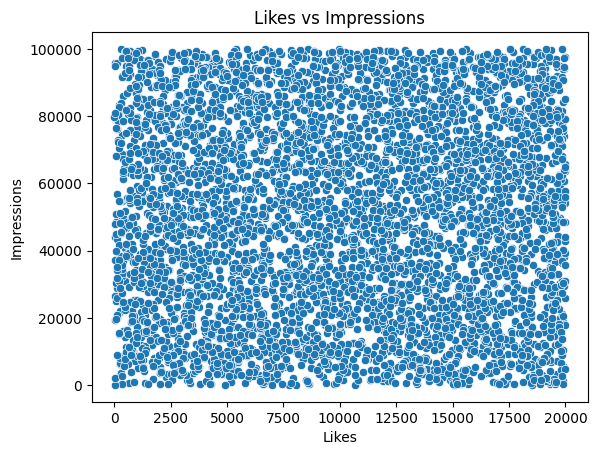

In [ ]:
sns.scatterplot(x="likes", y="impression_count", data=df)
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.title("Likes vs Impressions")
plt.show()

**Line: daily engagement trend**

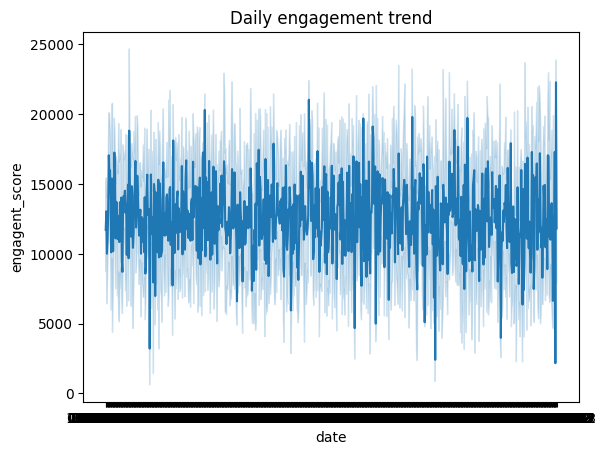

In [ ]:
sns.lineplot(x="posted_at",y="engagement_score",data=df)
plt.title("Daily engagement trend")
plt.xlabel("date")
plt.ylabel("engagent_score")
plt.show()

**Bar: posts by category**

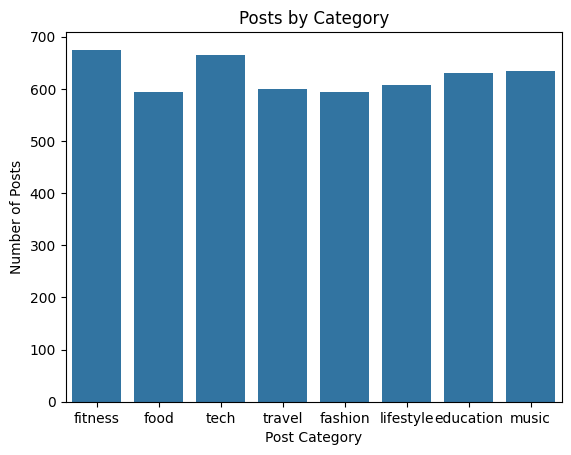

In [ ]:
sns.countplot(x="post_category", data=df)

plt.title("Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")

plt.show()

**Pie: gender distribution**

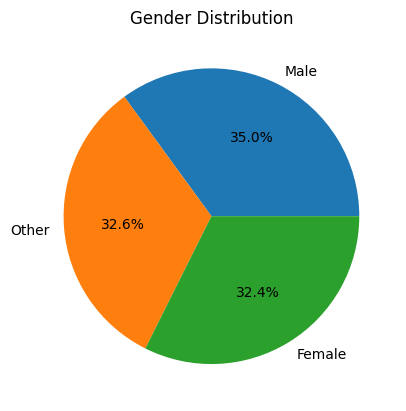

In [ ]:
gender_count = df["gender"].value_counts()

plt.pie(gender_count, labels=gender_count.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

**Histogram: age**

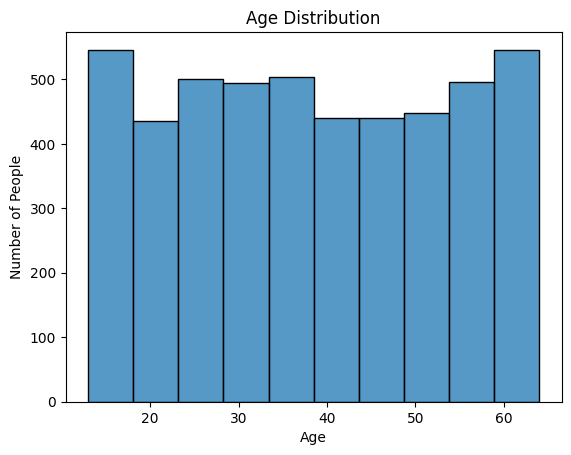

In [ ]:
sns.histplot(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()

**Box: engagement rate**

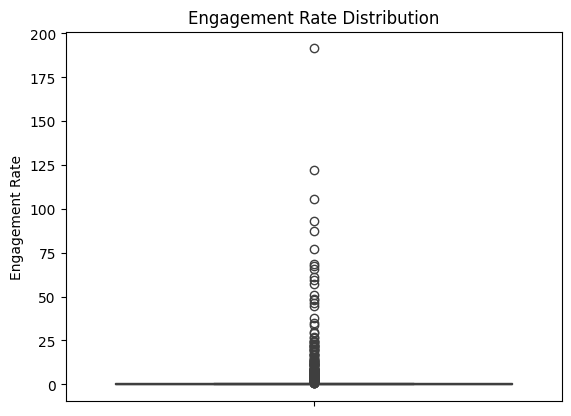

In [ ]:
sns.boxplot(y="engagement_rate", data=df)

plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate")
plt.show()

**Seaborn**

**Count plot: post type**

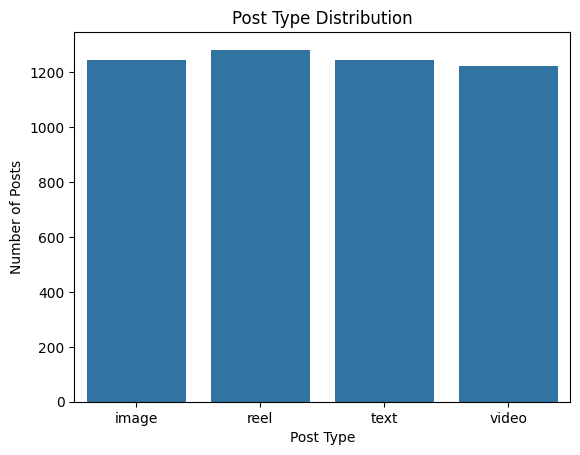

In [ ]:
sns.countplot(x="post_type", data=df)

plt.title("Post Type Distribution")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")

plt.show()

**Bar plot: avg likes by category**

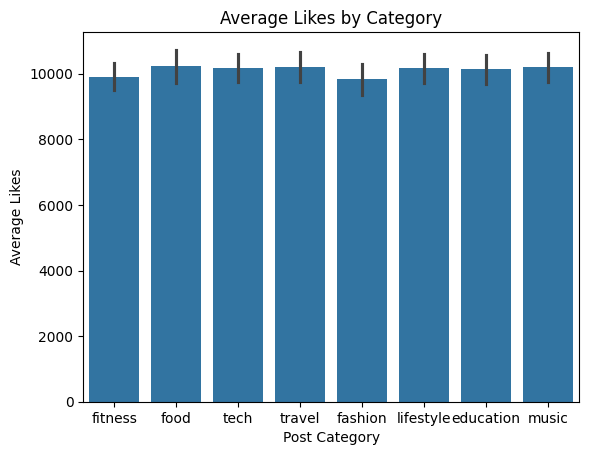

In [ ]:
sns.barplot(x="post_category", y="likes", data=df)

plt.title("Average Likes by Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")

plt.show()

**Violin: followers vs sentiment**

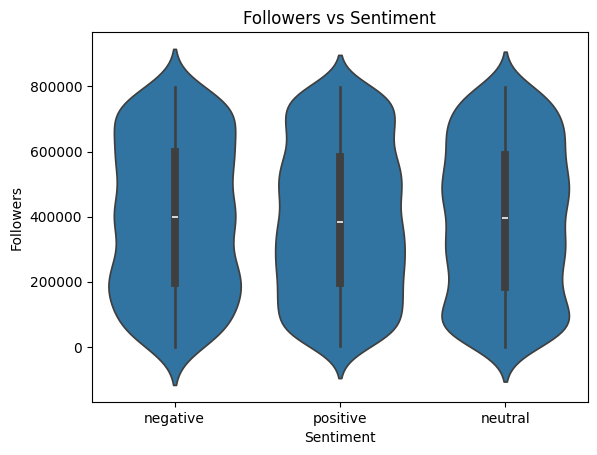

In [ ]:
sns.violinplot(x="sentiment", y="follower_count", data=df)

plt.title("Followers vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Followers")

plt.show()

**Pair plot: numeric features**

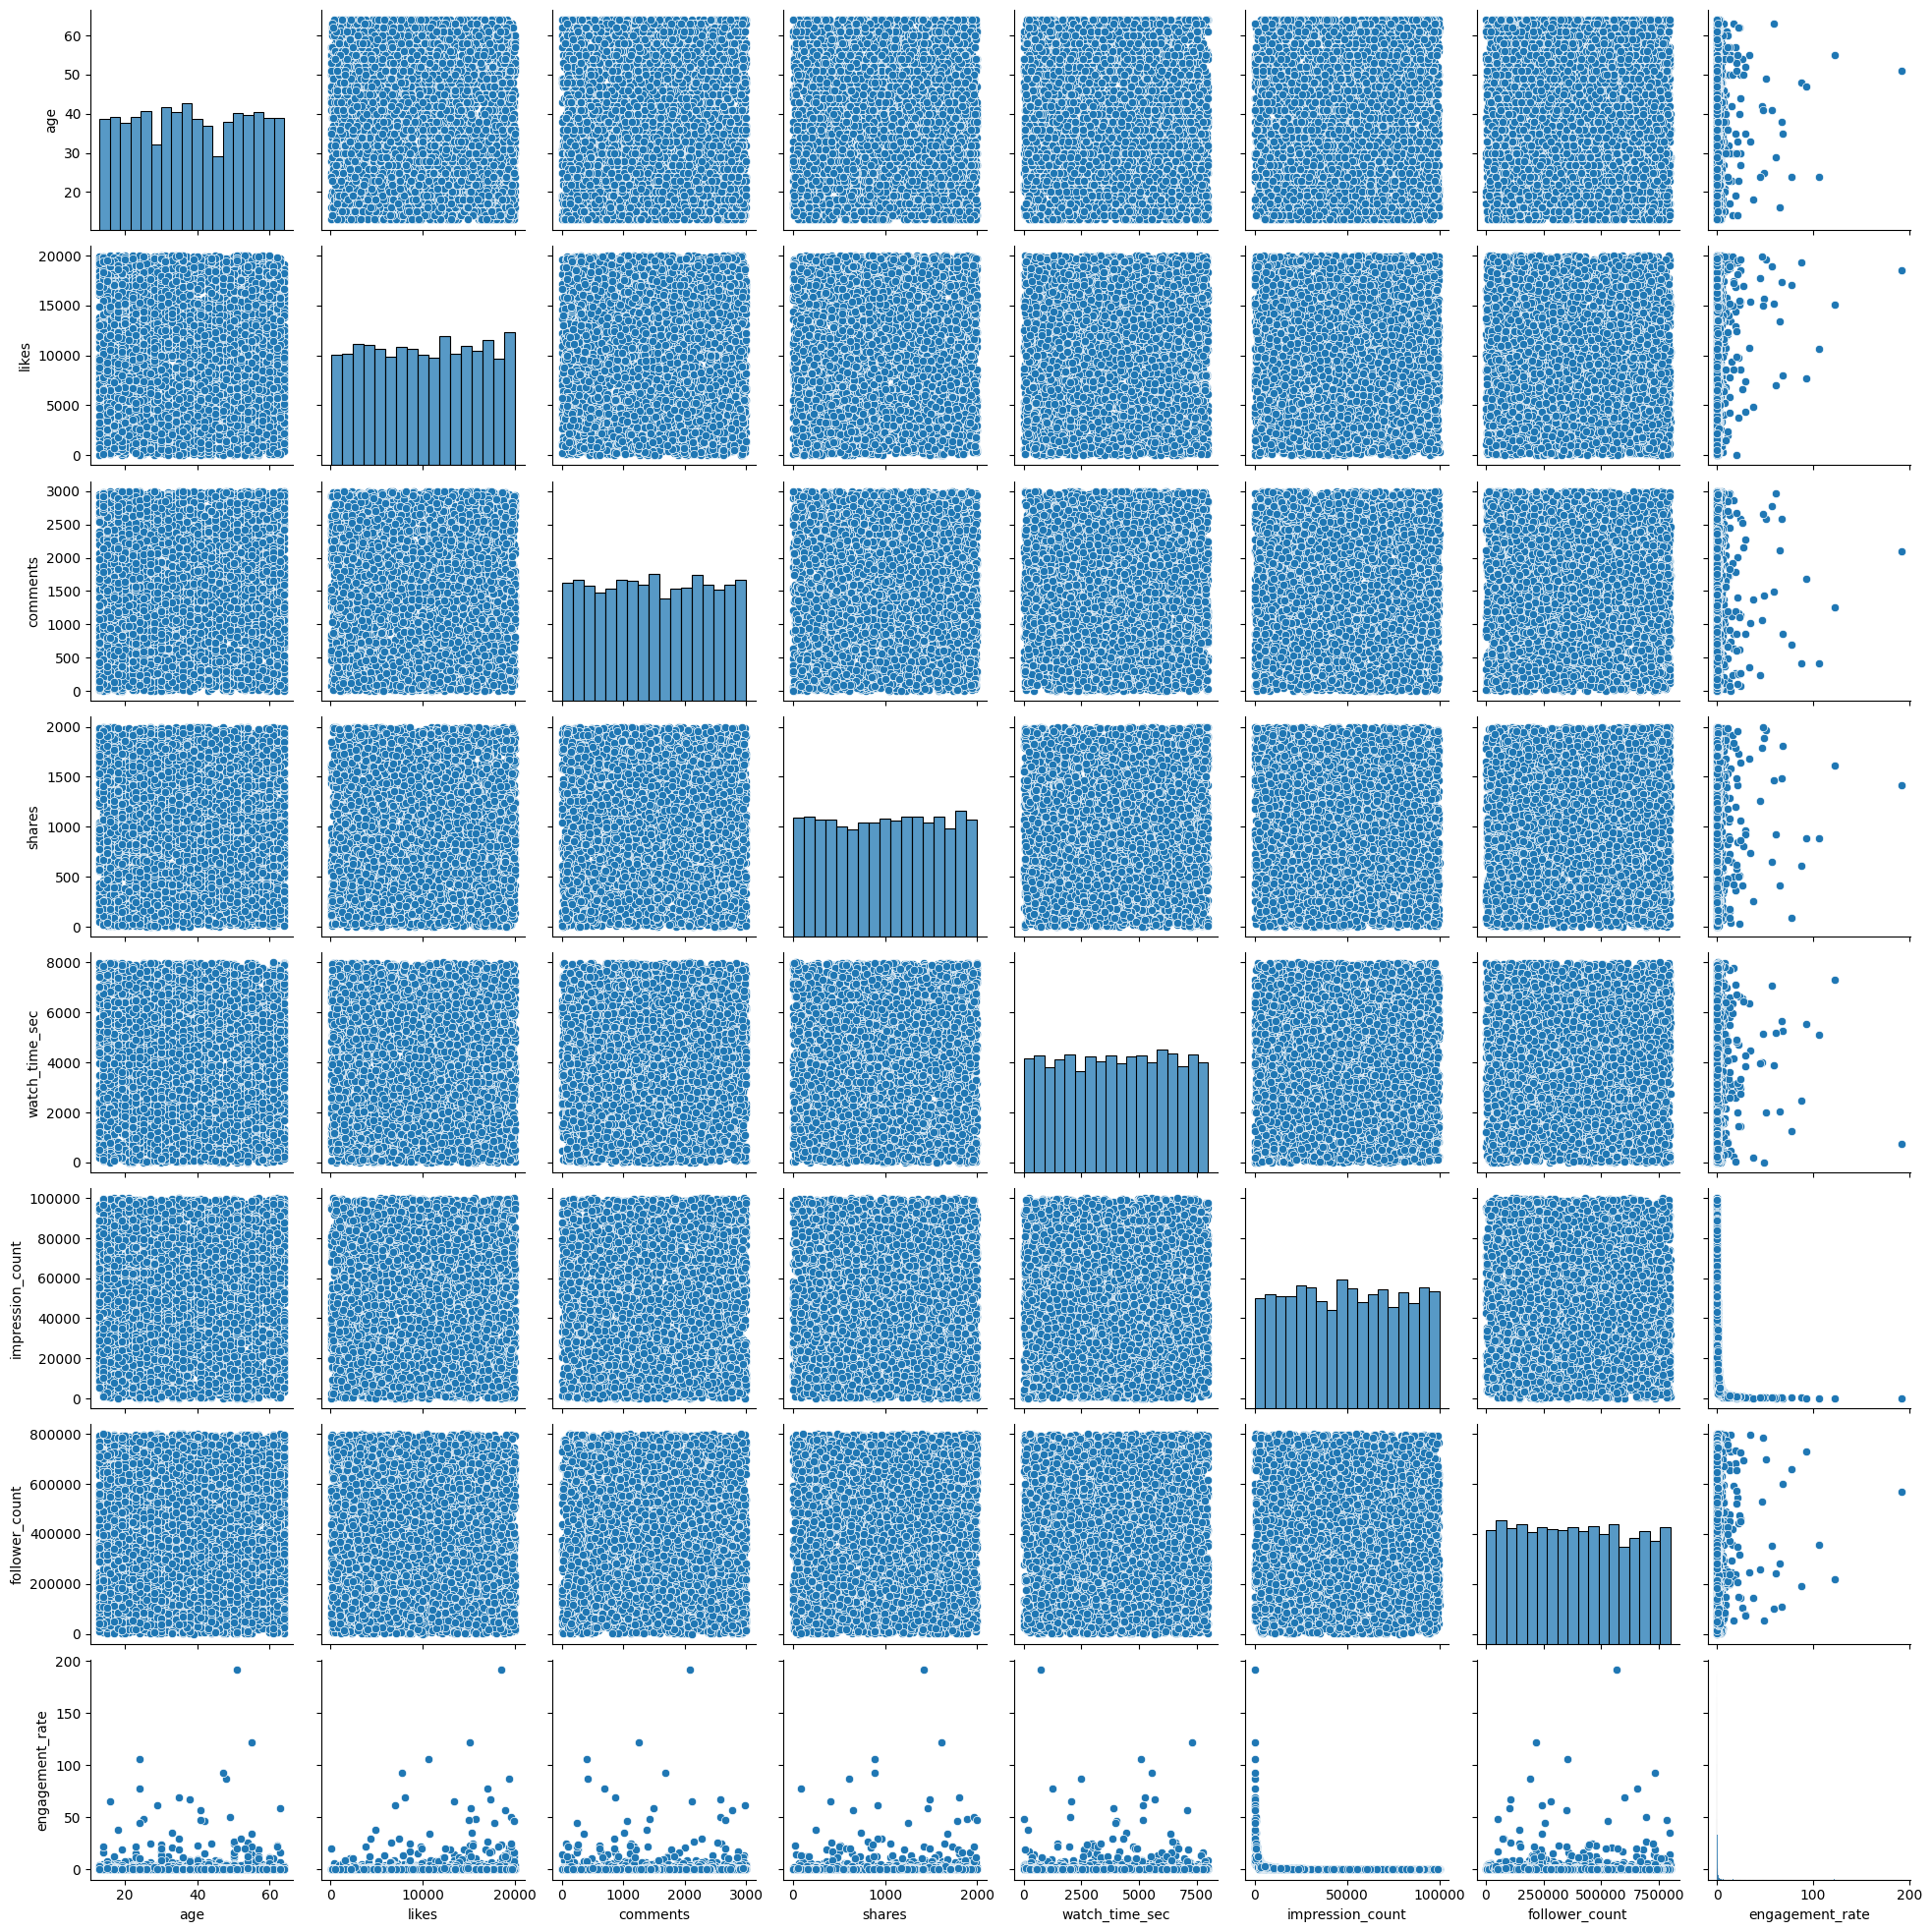

In [ ]:
numeric_cols = ["age", "likes", "comments", "shares",
                "watch_time_sec", "impression_count",
                "follower_count", "engagement_rate"]

sns.pairplot(df[numeric_cols])

plt.show()

**Heatmap: correlation matrix**

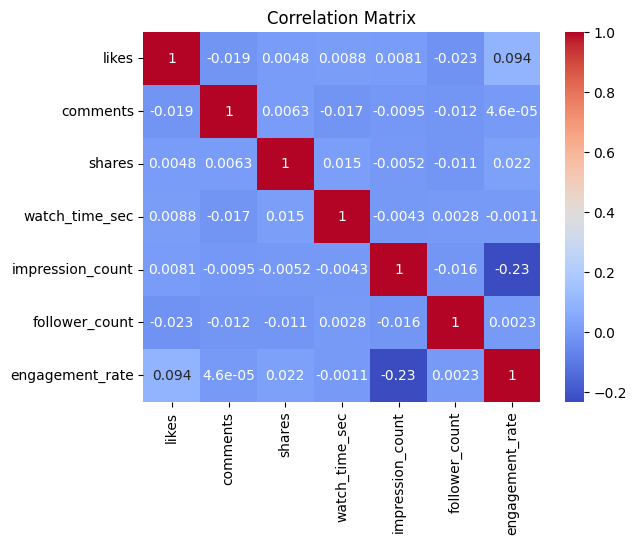

In [ ]:
corr = df[["likes", "comments", "shares",
           "watch_time_sec", "impression_count",
           "follower_count", "engagement_rate"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

**Swarm plot: engagement vs device**

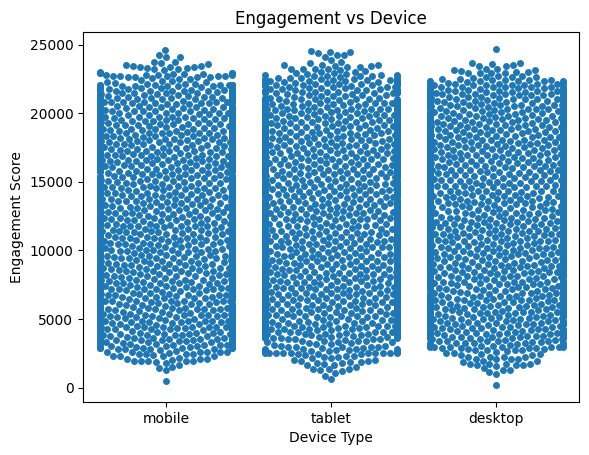

In [ ]:
sns.swarmplot(x="device_type", y="engagement_score", data=df)

plt.title("Engagement vs Device")
plt.xlabel("Device Type")
plt.ylabel("Engagement Score")
plt.show()

**Plotly (Interactive)
○ Interactive line chart/bar chart/bubble/scatter chart**

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="likes",
    y="impression_count",
    title="Likes vs Impressions"
)

fig.show()

#**Final Insights should include the following analysis:**

**Content Performance**

In [ ]:
#Which post types have the highest engagement?
df.groupby("post_type")["engagement_score"].mean().sort_values(ascending=False)

,engagement_score
post_type,
video,12658.675844
image,12627.062882
reel,12560.733850
text,12529.878199


In [ ]:
#Best-performing content category?
df.groupby("post_category")["engagement_score"].mean().sort_values(ascending=False)

,engagement_score
post_category,
music,12896.741710
food,12656.661710
tech,12649.633117
lifestyle,12616.940109
travel,12595.420857
education,12594.467826
fitness,12483.886614
fashion,12249.938889


In [ ]:
#Which countries have the highest average engagement rate?
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


**User Trends**

In [ ]:
#How age affects engagement
df.groupby("age")["engagement_score"].mean().sort_values(ascending=False)

,engagement_score
age,
49.0,14486.547619
17.0,14053.046512
33.0,13874.568182
39.0,13487.900000
36.0,13458.829787
38.0,13334.314815
20.0,13233.418919
14.0,13228.698925
24.0,13220.806122


In [ ]:
#Performance difference for verified accounts
df.groupby("is_verified")["engagement_score"].mean()

,engagement_score
is_verified,
False,12617.413223
True,12379.117517


#**Behavioral Insights**

In [ ]:
#Best time of day for impressions
df["posted_at"].dtype
df["hour"] = df["posted_at"].dt.hour
df.groupby("hour")["impression_count"].mean().sort_values(ascending=False)

,impression_count
hour,
0,50013.7328


In [ ]:
#Device type impact on watch time
df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)

,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


**Sentiment Analysis**

In [ ]:
#Which sentiment performs best
df.groupby("sentiment")["engagement_score"].mean().sort_values(ascending=False)

,engagement_score
sentiment,
negative,12745.962670
positive,12593.029963
neutral,12459.355160


In [ ]:
#Behavior of Negative / Neutral sentiment posts
df[df["sentiment"].isin(["negative", "neutral"])].groupby("sentiment")[["likes", "comments", "shares", "impression_count", "engagement_score"]].mean()

,likes,comments,shares,impression_count,engagement_score
sentiment,,,,,
negative,10211.406452,1516.584402,1007.186966,50191.960417,12745.96267
neutral,9917.785570,1529.270525,996.149966,49515.971185,12459.35516
